In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, AdaBoostRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, mean_squared_error, r2_score)

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
print("Shape:", df.shape)
df.head()

Shape: (7500, 16)


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [3]:
# Drop useless columns
df.drop(columns=['transaction_id', 'user_id'], inplace=True)

# Fill missing addiction_level with mode
df['addiction_level'].fillna(df['addiction_level'].mode()[0], inplace=True)

# Encode categorical columns
le = LabelEncoder()
for col in ['gender', 'stress_level', 'academic_work_impact', 'addiction_level']:
    df[col] = le.fit_transform(df[col])

print("Preprocessing Done!")
print(df.head())

Preprocessing Done!
   age  gender  daily_screen_time_hours  social_media_hours  gaming_hours  \
0   21       1                     3.23                2.01          0.89   
1   24       2                     5.09                3.81          2.24   
2   31       2                     6.06                1.36          3.83   
3   32       2                     7.83                5.85          1.51   
4   25       1                     9.96                5.92          3.42   

   work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
0              4.55         7.55                    248                154   
1              4.44         7.66                    127                 71   
2              2.35         4.92                     44                106   
3              3.54         8.23                    178                107   
4              5.27         6.21                    136                177   

   weekend_screen_time  stress_level  academic_w

C:\Users\kumar\AppData\Local\Temp\ipykernel_24352\2402093474.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['addiction_level'].fillna(df['addiction_level'].mode()[0], inplace=True)


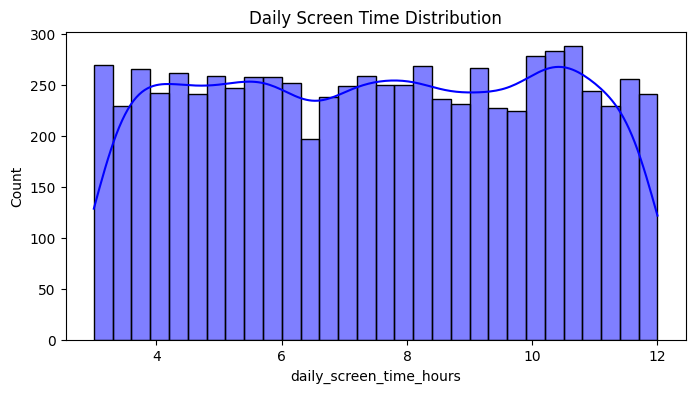

C:\Users\kumar\AppData\Local\Temp\ipykernel_24352\1572650565.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='addicted_label', data=df, palette='Set2')


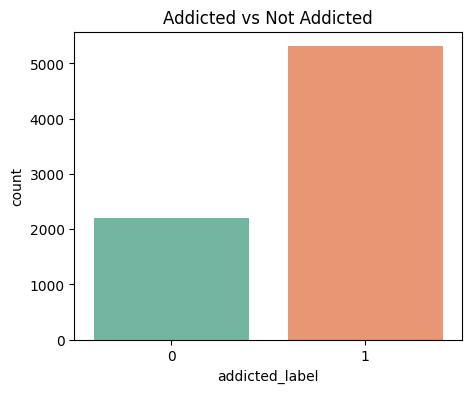

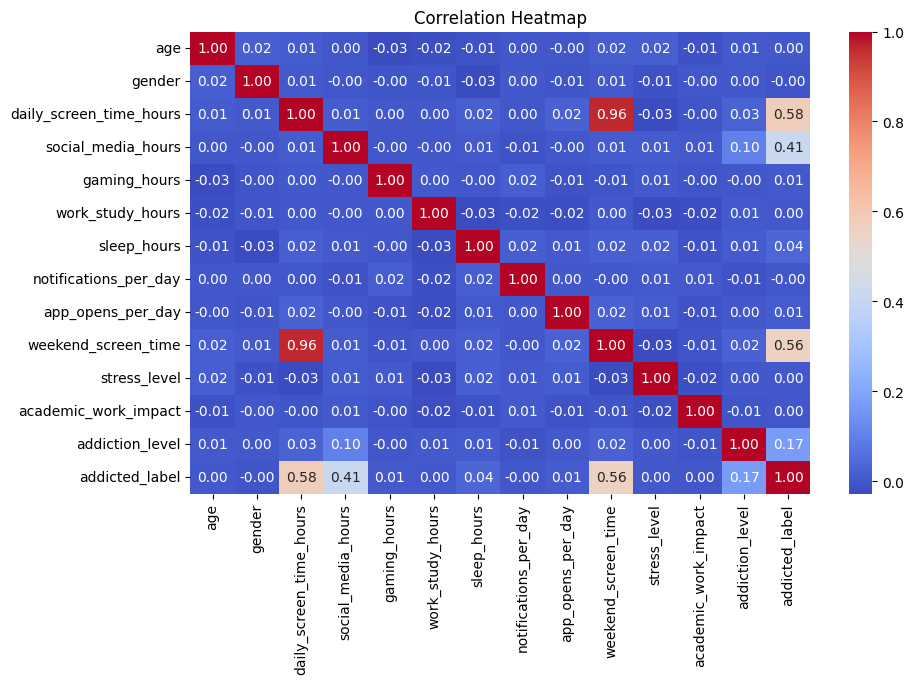

In [4]:
# Screen time distribution
plt.figure(figsize=(8,4))
sns.histplot(df['daily_screen_time_hours'], bins=30, kde=True, color='blue')
plt.title("Daily Screen Time Distribution")
plt.show()

# Addiction label count
plt.figure(figsize=(5,4))
sns.countplot(x='addicted_label', data=df, palette='Set2')
plt.title("Addicted vs Not Addicted")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

✅ Classification Results:
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       456
           1       1.00      1.00      1.00      1044

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



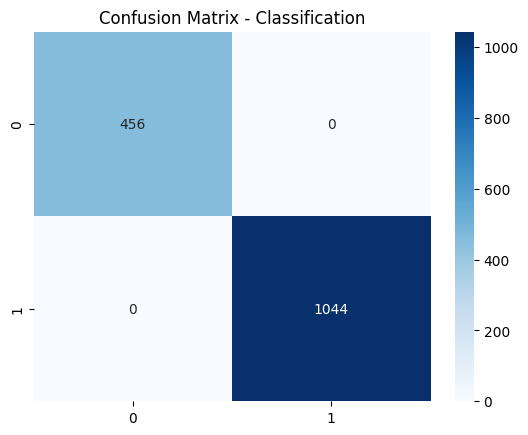

In [5]:
# Features and target
X_cls = df.drop(columns=['addicted_label', 'daily_screen_time_hours'])
y_cls = df['addicted_label']

# Scale
scaler = StandardScaler()
X_cls_scaled = scaler.fit_transform(X_cls)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_cls_scaled, y_cls, test_size=0.2, random_state=42)

# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("✅ Classification Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Classification")
plt.show()

✅ Regression Results:
R² Score: 0.9274
RMSE: 0.7137


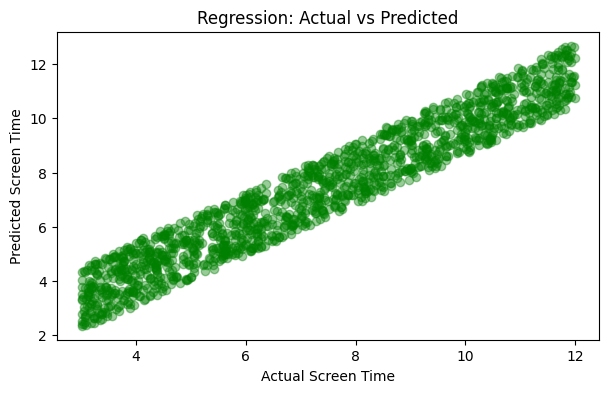

In [6]:
# Features and target
X_reg = df.drop(columns=['daily_screen_time_hours', 'addicted_label'])
y_reg = df['daily_screen_time_hours']

# Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_r, y_train_r)
y_pred_r = lr.predict(X_test_r)

print("✅ Regression Results:")
print("R² Score:", round(r2_score(y_test_r, y_pred_r), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_r, y_pred_r)), 4))

# Plot
plt.figure(figsize=(7,4))
plt.scatter(y_test_r, y_pred_r, alpha=0.4, color='green')
plt.xlabel("Actual Screen Time")
plt.ylabel("Predicted Screen Time")
plt.title("Regression: Actual vs Predicted")
plt.show()

In [7]:
# AdaBoost Classifier (before tuning)
ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
print("AdaBoost Accuracy (Before Tuning):", accuracy_score(y_test, y_pred_ada))

# GridSearchCV Tuning
params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}

grid = GridSearchCV(ada, params, cv=5, scoring='accuracy', verbose=1)
grid.fit(X_train, y_train)

print("\n✅ Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", round(grid.best_score_, 4))

# After tuning
best_ada = grid.best_estimator_
y_pred_best = best_ada.predict(X_test)
print("AdaBoost Accuracy (After Tuning):", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

AdaBoost Accuracy (Before Tuning): 1.0
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Best Parameters: {'learning_rate': 0.1, 'n_estimators': 50}
Best CV Accuracy: 1.0
AdaBoost Accuracy (After Tuning): 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       456
           1       1.00      1.00      1.00      1044

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



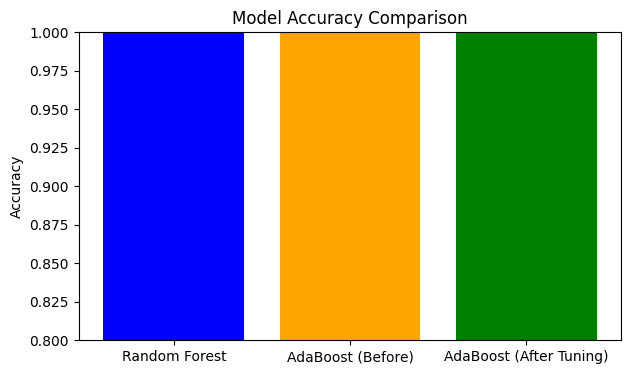

Random Forest: 100.0%
AdaBoost (Before): 100.0%
AdaBoost (After Tuning): 100.0%


In [8]:
results = {
    'Random Forest': accuracy_score(y_test, y_pred),
    'AdaBoost (Before)': accuracy_score(y_test, y_pred_ada),
    'AdaBoost (After Tuning)': accuracy_score(y_test, y_pred_best)
}

plt.figure(figsize=(7,4))
plt.bar(results.keys(), results.values(), color=['blue','orange','green'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.show()

for model, acc in results.items():
    print(f"{model}: {round(acc*100, 2)}%")